In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# Регрессия

1) Сначала познакомимся с простой линейной моделью и задачей подгонки прямой под облако точек.
Для этого нужно сгенерировать модельные данные: массив X, где Xk = k/m для m = 10, 20, 50,
и массив Y, где Yi = aXi + b + εi, где a, b – количество гласных в ваших имени и фамилии соответственно, случайные величины εi ∼ N (0, σ2) независимы (используйте σ = 1, σ = a/9).

(a) Найти оценки для коэффициентов прямой методом МНК (см. регрессия, OLS).

(b) Построить на одном графике облако точек, полученную прямую, исходную прямую.

(c) Сравнить полученные коэффициенты и оценку дисперсии ошибок с исходными.

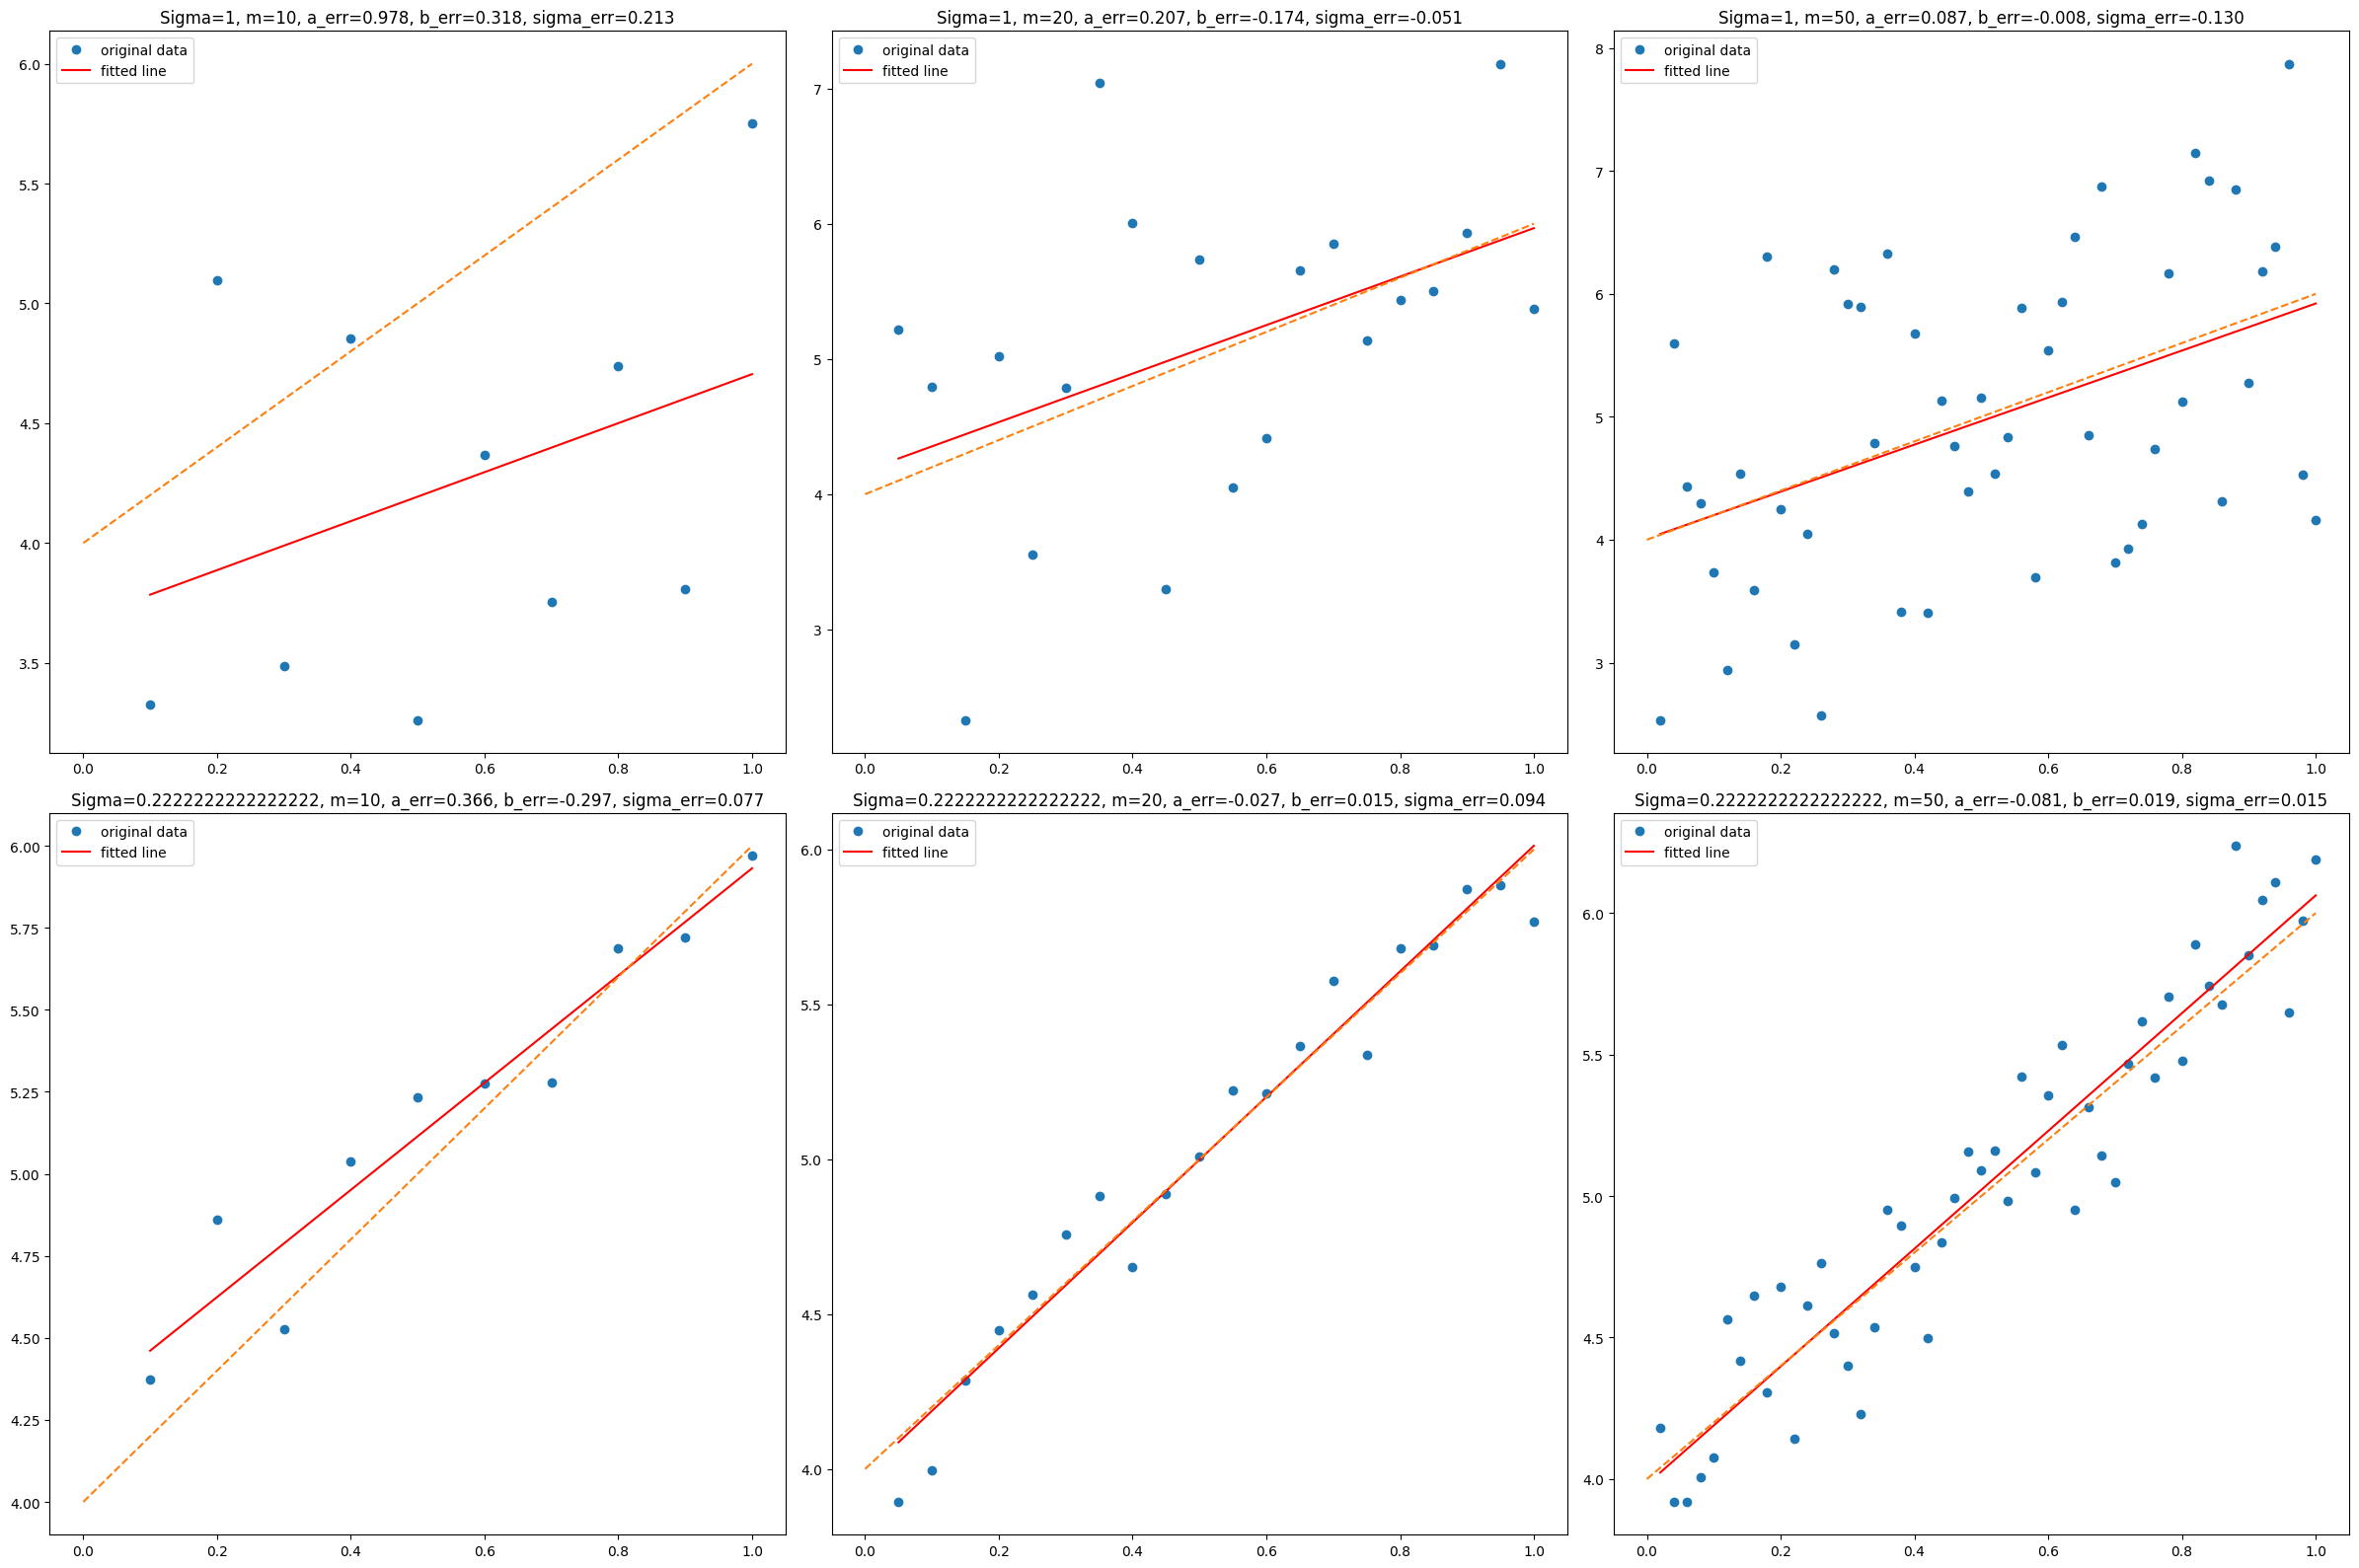

In [ ]:
a = 2
b = 4
sigma_vals = [1, a/9]
m_vals = [10,20,50]

fig, axes = fig, axes = plt.subplots(len(sigma_vals), len(m_vals), figsize=(24, 16))

for i in range(len(m_vals)):
  m = m_vals[i]
  for j in range(len(sigma_vals)):
    sigma = sigma_vals[j]

    #generate values
    x_data = np.array([(i+1)/m for i in range(m)])
    y_data = a*x_data + b + stats.norm.rvs(0, sigma, m)

    x=np.linspace(0,1,1000)
    res = stats.linregress(x_data, y_data)
    axes[j, i].plot(x_data, y_data, 'o', label='original data')
    axes[j,i].plot(x_data, res.intercept + res.slope*x_data, 'r', label='fitted line')
    axes[j,i].plot(x, a*x+b, linestyle='--')

    #errors of a,b,sigma
    a_error = a - res.slope
    b_error = b - res.intercept

    y_pred = res.slope * x_data + res.intercept
    residuals = y_data - y_pred
    sigma_est = np.sqrt(np.sum(residuals**2) / (m - 1))
    sigma_error = sigma - sigma_est

    axes[j, i].set_title(f'Sigma={sigma}, m={m}, a_err={a_error:.3f}, b_err={b_error:.3f}, sigma_err={sigma_error:.3f}')
    axes[j,i].legend()


plt.legend()
plt.tight_layout()


2) Теперь посмотрим, как наши методы реагируют на сильно отклоняющиеся от прямой значения Y .
Для этого в массиве Y нужно изменить несколько элементов.

(a) Пусть Yt = aXt + b + 5σ для некоторого (одного!) t. Построить новую прямую методом МНК,
сравнить с прямой МНК, построенной в задаче 1. Рассмотреть случаи, когда Xt находится в
центре массива и когда Xt расположен на краю.

(b) Если Yt = aXt +b+5σ, а Ys = aXs +b−5σ, будут ли эти выбросы компенсировать друг друга?
Рассмотреть случаи, когда Xt, Xs находятся а) рядом б) на разных концах ряда.

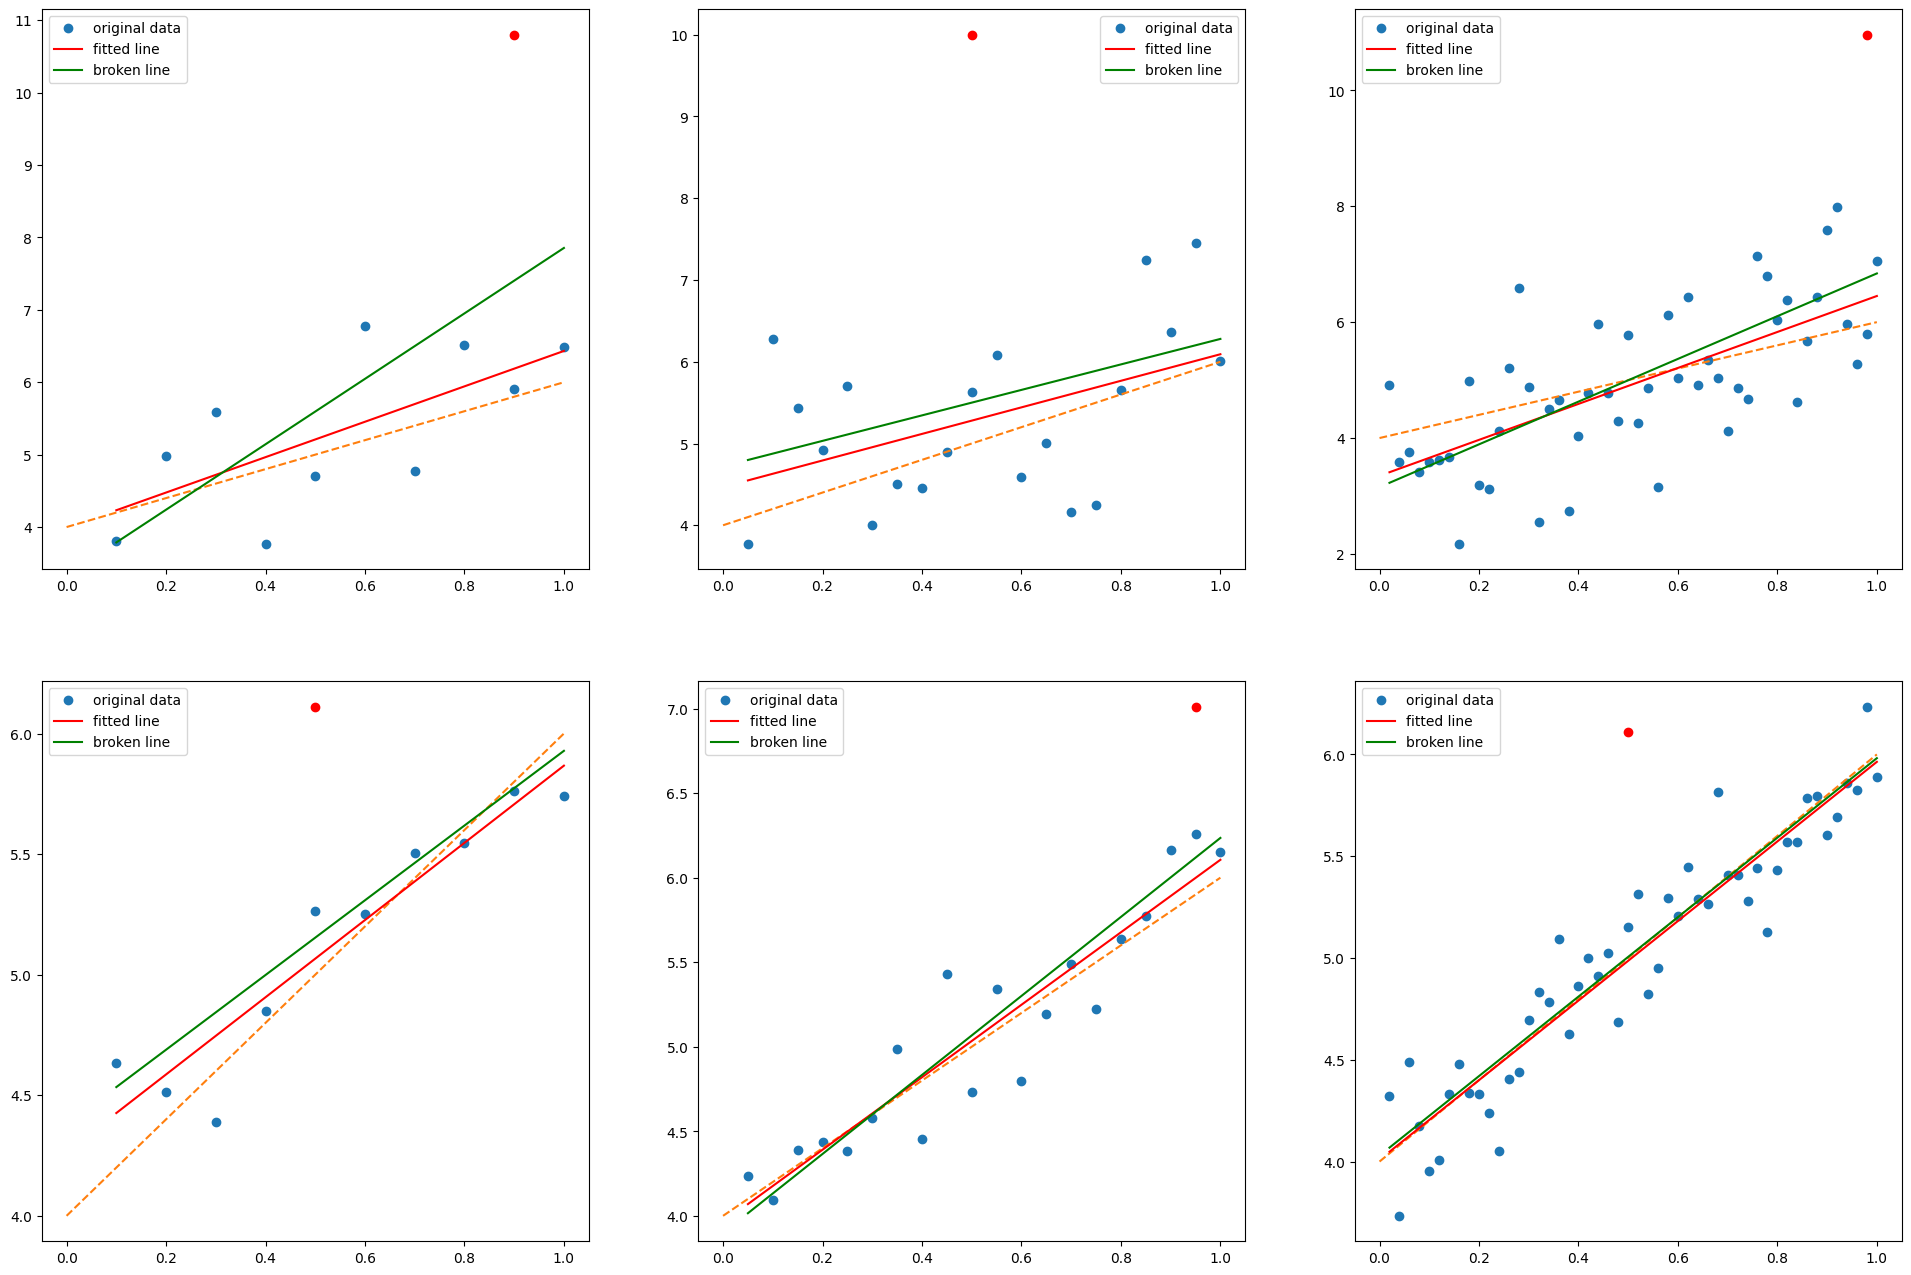

In [ ]:
a = 2
b = 4
sigma_vals = [1, a/9]
m_vals = [10,20,50]

fig, axes = fig, axes = plt.subplots(len(sigma_vals), len(m_vals), figsize=(24, 16))

for i in range(len(m_vals)):
  m = m_vals[i]
  for j in range(len(sigma_vals)):
    sigma = sigma_vals[j]

    #generate values
    x_data = np.array([(i+1)/m for i in range(m)])
    y_data = a*x_data + b + stats.norm.rvs(0, sigma, m)
    axes[j, i].plot(x_data, y_data, 'o', label='original data')

    x=np.linspace(0,1,1000)
    axes[j, i].plot(x, a*x+b, linestyle='--')

    #linregress classic
    res = stats.linregress(x_data, y_data)
    axes[j, i].plot(x_data, res.intercept + res.slope*x_data, 'r', label='fitted line')

    #break data
    if (i+j)%2 == 0:
      t = m-1
    else:
      t = m//2
    y_data[t-1] = a*x_data[t-1] + b + 5*sigma
    axes[j,i].plot(x_data[t-1], y_data[t-1], 'o', color = 'red')
    res = stats.linregress(x_data, y_data)
    axes[j, i].plot(x_data, res.intercept + res.slope*x_data, 'g', label='broken line')

    axes[j, i].legend()

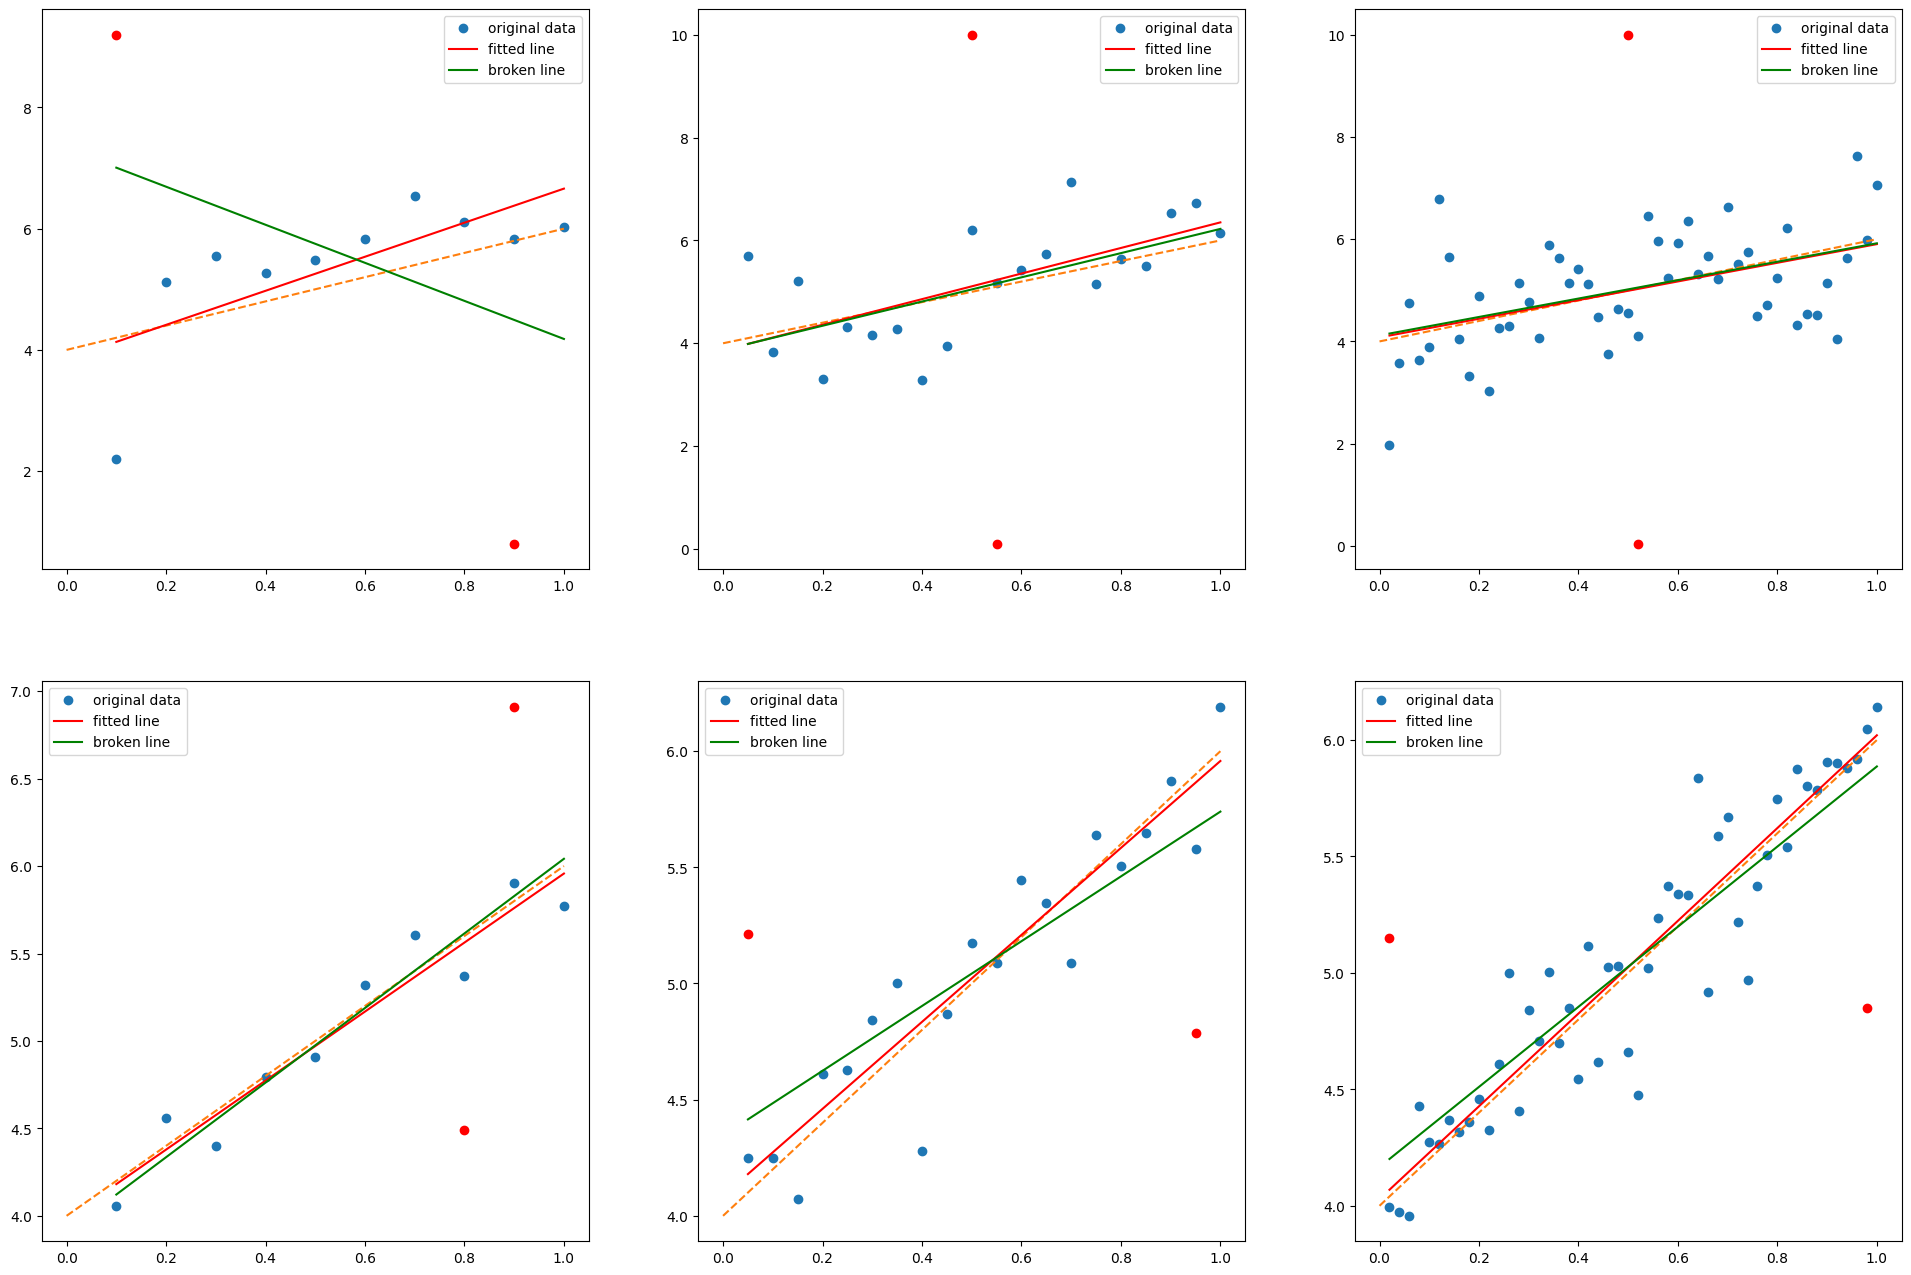

In [ ]:
a = 2
b = 4
sigma_vals = [1, a/9]
m_vals = [10,20,50]



fig, axes = fig, axes = plt.subplots(len(sigma_vals), len(m_vals), figsize=(24, 16))

for i in range(len(m_vals)):
  m = m_vals[i]
  for j in range(len(sigma_vals)):
    sigma = sigma_vals[j]

    #generate values
    x_data = np.array([(i+1)/m for i in range(m)])
    y_data = a*x_data + b + stats.norm.rvs(0, sigma, m)
    axes[j, i].plot(x_data, y_data, 'o', label='original data')

    x=np.linspace(0,1,1000)
    axes[j, i].plot(x, a*x+b, linestyle='--')

    #linregress classic
    res = stats.linregress(x_data, y_data)
    axes[j, i].plot(x_data, res.intercept + res.slope*x_data, 'r', label='fitted line')

    #break data
    if (j,i) in [(0,0), (1, 2), (1,1)]:
      t,s = 1, m-1
    elif (j,i) in [(0,1), (0,2)]:
      t,s = m//2, m//2+1
    else:
      t,s = m-1, m-2

    y_data[t-1] = a*x_data[t-1] + b + 5*sigma
    y_data[s-1] = a*x_data[s-1] + b - 5*sigma

    axes[j,i].plot(x_data[t-1], y_data[t-1], 'o', color = 'red')
    axes[j,i].plot(x_data[s-1], y_data[s-1], 'o', color = 'red')

    res = stats.linregress(x_data, y_data)
    axes[j, i].plot(x_data, res.intercept + res.slope*x_data, 'g', label='broken line')

    axes[j, i].legend()

3) Познакомимся с общей линейной моделью. Посмотрим, как метод МНК работает для подгонки
многочлена. Пусть X – тот же массив, Yi = a0 + a1Xi + · · · + ak*X^k_i + εi, εi ∼ N (0, σ2) независимы (σ = 1).

(a) Построить МНК-оценки коэффициентов, считая что Y = a0 + a1X + · · · + adXd
i + ε, где d = k, k + 1, k + 3, сравнить их с исходными.

(b) Построить на одном графике облако точек, полученный многочлен, исходный многочлен (от-
дельно для разных d).

(c) Построить прогноз в точках x = 1.2, 1.5, 2 для разных d, сравнить эти прогнозы.

(d) Сравнить графики многочленов, полученных в задаче при разных d, за пределами отрезка
[0, 1].

1ый вариант: y = x^4 − 3x^2 + x + 1,

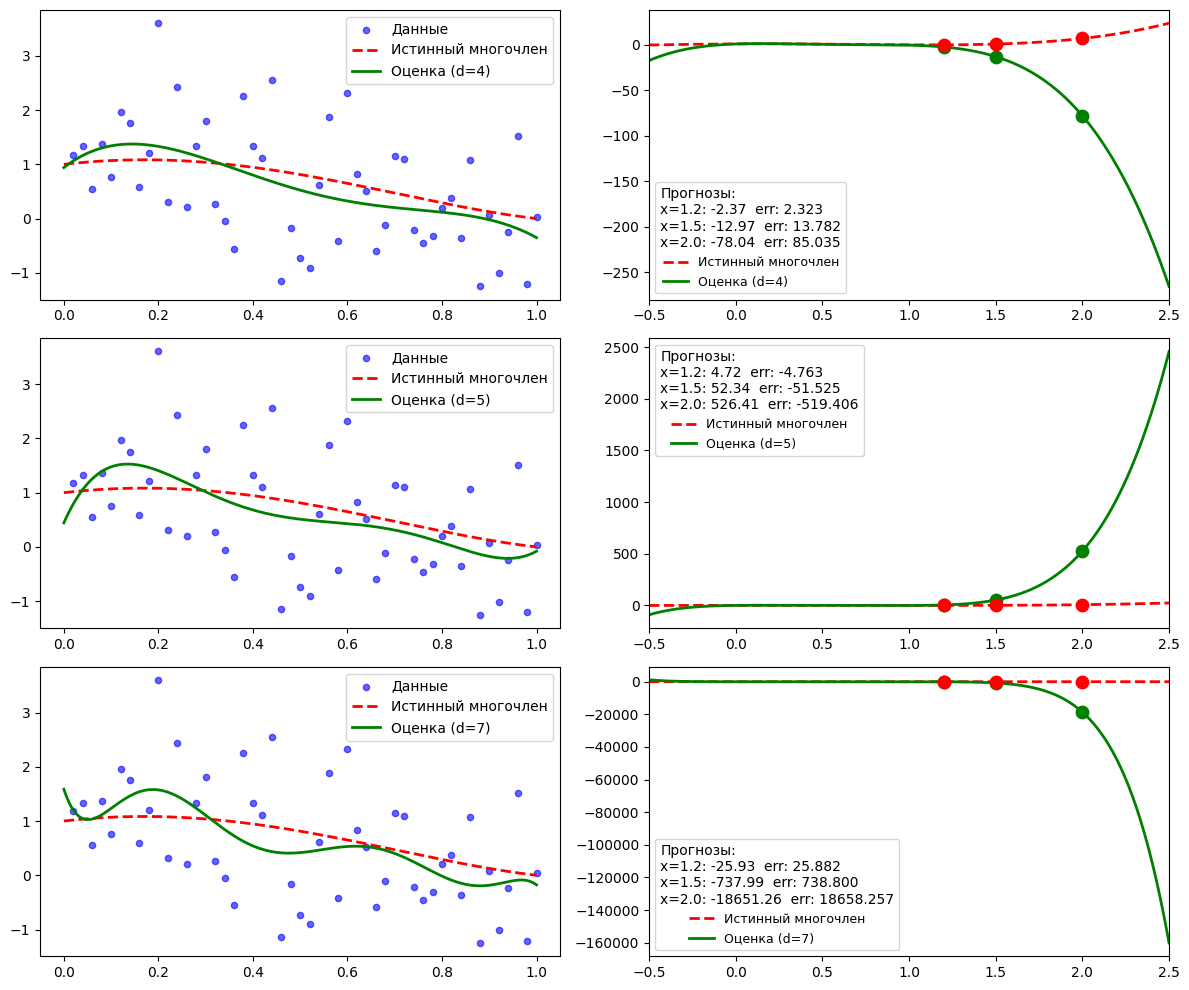

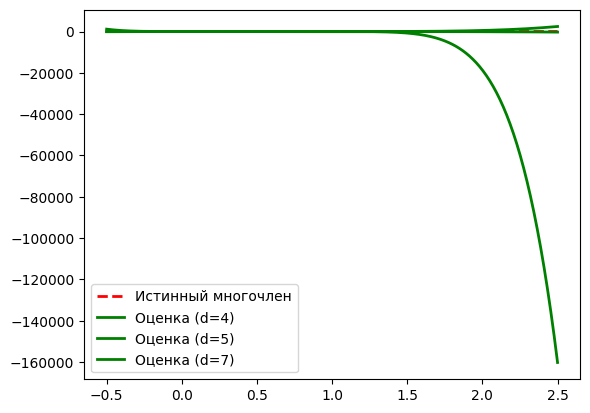

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

sigma = 1
k = 4
m = 50

def p(x):
    return x**4 - 3*x**2 + x + 1

d_vals = [k, k+1, k+3]
test_points = [1.2, 1.5, 2.0]

fig, axes = plt.subplots(len(d_vals), 2, figsize=(12, 10))

# generate data
x_data = np.array([(j+1)/m for j in range(m)])
y_true = p(x_data)
y_data = y_true + stats.norm.rvs(0, sigma, m)

outside_compare = []

for i, d in enumerate(d_vals):

    # generate x**k data
    poly_features = PolynomialFeatures(degree=d, include_bias=True)
    X_poly = poly_features.fit_transform(x_data.reshape(-1, 1))

    # do linreg
    # (XᵀX)⁻¹Xᵀy
    model = LinearRegression(fit_intercept=False)
    model.fit(X_poly, y_data)

    x_inside = np.linspace(0, 1, 200)
    X_inside_poly = poly_features.transform(x_inside.reshape(-1, 1))
    y_inside_pred = model.predict(X_inside_poly)
    y_inside_true = p(x_inside)

    x_outside = np.linspace(-0.5, 2.5, 400)
    X_outside_poly = poly_features.transform(x_outside.reshape(-1, 1))
    y_outside_pred = model.predict(X_outside_poly)
    y_outside_true = p(x_outside)

    outside_compare.append(y_outside_pred)

    predictions = []
    for point in test_points:
        X_point = poly_features.transform(np.array([[point]]))
        prediction = model.predict(X_point)[0]
        predictions.append((point, prediction, p(point)))

    #left graph
    axes[i, 0].scatter(x_data, y_data, alpha=0.6, s=20, color='blue', label='Данные')
    axes[i, 0].plot(x_inside, y_inside_true, 'r--', linewidth=2, label='Истинный многочлен')
    axes[i, 0].plot(x_inside, y_inside_pred, 'g-', linewidth=2, label=f'Оценка (d={d})')
    axes[i, 0].set_xlim(-0.05, 1.05)
    axes[i, 0].legend()

    #right graph
    axes[i, 1].plot(x_outside, y_outside_true, 'r--', linewidth=2, label='Истинный многочлен')
    axes[i, 1].plot(x_outside, y_outside_pred, 'g-', linewidth=2, label=f'Оценка (d={d})')

    legend_text = f'Прогнозы:\n'
    for point, pred, true in predictions:
        axes[i, 1].scatter(point, pred, s=80, marker='o', zorder=5, color='green')
        axes[i, 1].scatter(point, true, s=80, marker='o', zorder=5, color='red')
        legend_text += f'x={point}: {pred:.2f}  err: {(true-pred):.3f}\n'
    axes[i, 1].set_xlim(-0.5, 2.5)
    axes[i, 1].legend(title=legend_text.strip(), loc='best', fontsize=9)

plt.tight_layout()
plt.show()


#compare graphs next to each other
plt.plot(x_outside, y_outside_true, 'r--', linewidth=2, label='Истинный многочлен')

for j in range(len(d_vals)):
  d = d_vals[j]
  y_pred_c = outside_compare[j]
  plt.plot(x_outside, y_pred_c, 'g-', linewidth=2, label=f'Оценка (d={d})')

plt.legend()
